In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

# ----------------------------------------------------
# 1. Load evaluation result files
# ----------------------------------------------------
files = {
    "VDJdb score 0": "output/models/0.08_mst_enrich/results/max/vdj0.csv",
    "VDJdb score 1": "output/models/0.08_mst_enrich/results/max/vdj1.csv",
    "VDJdb score 2": "output/models/0.08_mst_enrich/results/max/vdj2.csv",
    "VDJdb score 3": "output/models/0.08_mst_enrich/results/max/vdj3.csv",
    "Test set": "output/models/0.08_mst_enrich/results/max/test.csv",
    "No exclusion": "output/models/0.08_mst_enrich/results/max/none_excluded_vdj0.csv",
    "TCR excluded": "output/models/0.08_mst_enrich/results/max/cdr3_excluded_vdj0.csv",
    "Epitope excluded": "output/models/0.08_mst_enrich/results/max/peptide_excluded_vdj0.csv",
    "TCR & Epitope excluded": "output/models/0.08_mst_enrich/results/max/cdr3_and_peptide_excluded_vdj0.csv",
}

dfs = {name: pd.read_csv(path) for name, path in files.items()}

# ----------------------------------------------------
# 2. Compute metrics
# ----------------------------------------------------
results = {}

for name, df in dfs.items():
    y_true = df["true_label"].values
    y_pred = df["predicted_binding_prob"].values

    auc = roc_auc_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred >= 0.5)

    results[name] = {
        "AUROC": auc,
        "Accuracy": acc,
        "N": len(df)
    }

results_df = pd.DataFrame(results).T
print(results_df)


                           AUROC  Accuracy        N
VDJdb score 0           0.624326  0.582651  18318.0
VDJdb score 1           0.675528  0.606416  16863.0
VDJdb score 2           0.629345  0.598299   4822.0
VDJdb score 3           0.603140  0.568668   2432.0
Test set                0.743903  0.670600  15000.0
No exclusion            0.683886  0.643667  30000.0
TCR excluded            0.673163  0.633067  30000.0
Epitope excluded        0.665153  0.626476  26001.0
TCR & Epitope excluded  0.668608  0.624004  25479.0


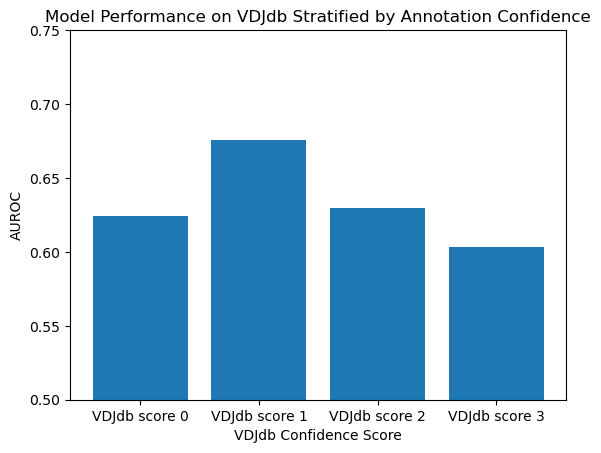

In [19]:
vdj_scores = ["VDJdb score 0", "VDJdb score 1", "VDJdb score 2", "VDJdb score 3"]
vdj_auroc = [results[s]["AUROC"] for s in vdj_scores]

plt.figure()
plt.bar(vdj_scores, vdj_auroc)
plt.ylabel("AUROC")
plt.xlabel("VDJdb Confidence Score")
plt.title("Model Performance on VDJdb Stratified by Annotation Confidence")
plt.ylim(0.5, 0.75)
plt.show()


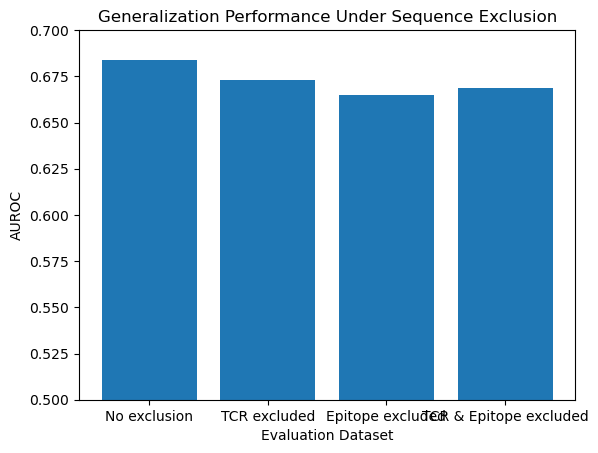

In [20]:
generalization_sets = [
    "No exclusion",
    "TCR excluded",
    "Epitope excluded",
    "TCR & Epitope excluded"
]

gen_auroc = [results[s]["AUROC"] for s in generalization_sets]

plt.figure()
plt.bar(generalization_sets, gen_auroc)
plt.ylabel("AUROC")
plt.xlabel("Evaluation Dataset")
plt.title("Generalization Performance Under Sequence Exclusion")
plt.ylim(0.5, 0.7)
plt.show()


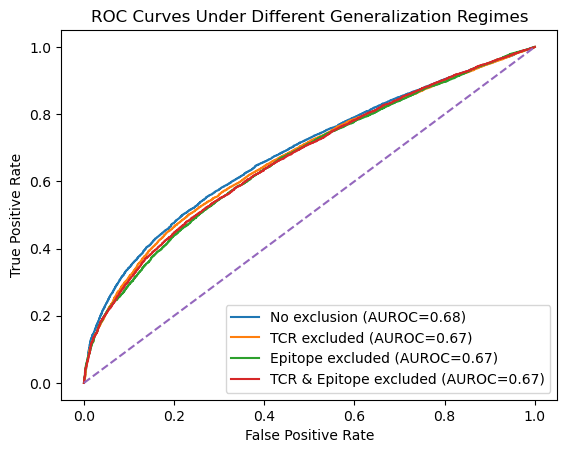

In [21]:
plt.figure()

for name in generalization_sets:
    df = dfs[name]
    fpr, tpr, _ = roc_curve(df["true_label"], df["predicted_binding_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUROC={results[name]['AUROC']:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Under Different Generalization Regimes")
plt.legend()
plt.show()


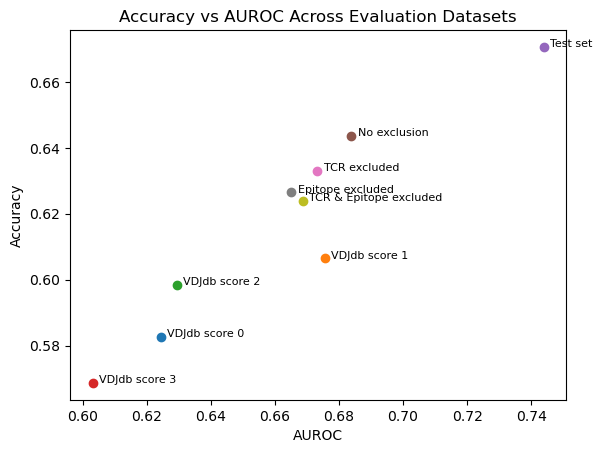

In [22]:
plt.figure()

for name, vals in results.items():
    plt.scatter(vals["AUROC"], vals["Accuracy"])
    plt.text(vals["AUROC"] + 0.002, vals["Accuracy"], name, fontsize=8)

plt.xlabel("AUROC")
plt.ylabel("Accuracy")
plt.title("Accuracy vs AUROC Across Evaluation Datasets")
plt.show()


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)
from sklearn.calibration import calibration_curve


# -----------------------------
# Config: point to your CSV files
# Each CSV must contain: true_label, predicted_binding_prob
# -----------------------------
DATASETS = {
    "VDJdb score 0": "output/models/0.08_mst_enrich/results/max/vdj0.csv",
    "VDJdb score 1": "output/models/0.08_mst_enrich/results/max/vdj1.csv",
    "VDJdb score 2": "output/models/0.08_mst_enrich/results/max/vdj2.csv",
    "VDJdb score 3": "output/models/0.08_mst_enrich/results/max/vdj3.csv",
    "Random split (none excluded)": "output/models/0.08_mst_enrich/results/max/none_excluded_vdj0.csv",
    "TCR excluded": "output/models/0.08_mst_enrich/results/max/cdr3_excluded_vdj0.csv",
    "Epitope excluded": "output/models/0.08_mst_enrich/results/max/peptide_excluded_vdj0.csv",
    "TCR+Epitope excluded": "output/models/0.08_mst_enrich/results/max/cdr3_and_peptide_excluded_vdj0.csv",
}

OUTDIR = "thesis_figures"
os.makedirs(OUTDIR, exist_ok=True)

VDJ_ORDER = ["VDJdb score 0", "VDJdb score 1", "VDJdb score 2", "VDJdb score 3"]
GEN_ORDER = [
    "Random split (none excluded)",
    "TCR excluded",
    "Epitope excluded",
    "TCR+Epitope excluded",
]
HARD_SPLIT_NAME = "TCR+Epitope excluded"


# -----------------------------
# Helpers
# -----------------------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"true_label", "predicted_binding_prob"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {missing}")

    df["true_label"] = df["true_label"].astype(int)
    df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)
    return df

def savefig(filename: str):
    outpath = os.path.join(OUTDIR, filename)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220, bbox_inches="tight")
    plt.close()
    print(f"Saved: {outpath}")

def pr_auc(y: np.ndarray, p: np.ndarray) -> float:
    # AUC under the Precision–Recall curve (AUPRC)
    precision, recall, _ = precision_recall_curve(y, p)
    return auc(recall, precision)

def f1_from_pr(precision: np.ndarray, recall: np.ndarray) -> np.ndarray:
    return 2 * precision * recall / (precision + recall + 1e-12)


# -----------------------------
# Load datasets
# -----------------------------
dfs = {name: load_df(path) for name, path in DATASETS.items()}


# -----------------------------
# (0) Metrics summary CSV (AUROC + AUPRC)
# -----------------------------
rows = []
for name, df in dfs.items():
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    rows.append({
        "Dataset": name,
        "N": len(df),
        "Positive rate": float(np.mean(y)),
        "AUROC": float(roc_auc_score(y, p)),
        "AUC_PR (AUPRC)": float(pr_auc(y, p)),
    })

metrics = pd.DataFrame(rows).sort_values("Dataset")
metrics.to_csv(os.path.join(OUTDIR, "00_metrics_summary_auroc_auprc.csv"), index=False)
print("Saved:", os.path.join(OUTDIR, "00_metrics_summary_auroc_auprc.csv"))


# -----------------------------
# (1) ROC curves across all datasets
# -----------------------------
plt.figure(figsize=(7.2, 5.2))
for name, df in dfs.items():
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    fpr, tpr, _ = roc_curve(y, p)
    auroc = roc_auc_score(y, p)
    plt.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves across evaluation datasets")
plt.legend(fontsize=7, loc="lower right", frameon=False)
savefig("01_roc_all_datasets.png")


# -----------------------------
# (2) Precision–Recall curves across all datasets (with AUPRC)
# -----------------------------
plt.figure(figsize=(7.2, 5.2))
for name, df in dfs.items():
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    precision, recall, _ = precision_recall_curve(y, p)
    auprc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC_PR={auprc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall curves across evaluation datasets")
plt.legend(fontsize=7, loc="lower left", frameon=False)
savefig("02_pr_all_datasets.png")


# -----------------------------
# (3) VDJdb confidence strata: AUROC + AUC_PR vs score (0–3)
# -----------------------------
auroc_vals, auprc_vals = [], []
for name in VDJ_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    auroc_vals.append(roc_auc_score(y, p))
    auprc_vals.append(pr_auc(y, p))

x = np.arange(len(VDJ_ORDER))
plt.figure(figsize=(7.0, 4.2))
plt.bar(x - 0.18, auroc_vals, width=0.36, label="AUROC")
plt.bar(x + 0.18, auprc_vals, width=0.36, label="AUC_PR (AUPRC)")
plt.xticks(x, ["0", "1", "2", "3"])
plt.ylim(0, 1.0)
plt.xlabel("VDJdb confidence score")
plt.ylabel("Metric value")
plt.title("Performance vs. VDJdb confidence strata")
plt.legend(frameon=False)
savefig("03_vdj_score_metrics_bar.png")


# -----------------------------
# (4) Generalization splits: AUROC + AUC_PR across overlap-exclusion splits
# -----------------------------
auroc_vals, auprc_vals = [], []
for name in GEN_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    auroc_vals.append(roc_auc_score(y, p))
    auprc_vals.append(pr_auc(y, p))

x = np.arange(len(GEN_ORDER))
plt.figure(figsize=(8.6, 4.2))
plt.bar(x - 0.18, auroc_vals, width=0.36, label="AUROC")
plt.bar(x + 0.18, auprc_vals, width=0.36, label="AUC_PR (AUPRC)")
plt.xticks(
    x,
    ["Random", "No TCR overlap", "No epitope overlap", "No TCR+epitope overlap"],
    rotation=15, ha="right"
)
plt.ylim(0, 1.0)
plt.ylabel("Metric value")
plt.title("Generalization across overlap-exclusion splits")
plt.legend(frameon=False)
savefig("04_generalization_splits_metrics_bar.png")


# -----------------------------
# (5) Calibration curves for generalization splits (optional but thesis-friendly)
# -----------------------------
plt.figure(figsize=(7.2, 5.2))
for name in GEN_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curves for generalization splits")
plt.legend(fontsize=8, frameon=False, loc="upper left")
savefig("05_calibration_generalization_splits.png")


# -----------------------------
# (6) Predicted probability distributions by class (hardest split)
# -----------------------------
df = dfs[HARD_SPLIT_NAME]
p_pos = df.loc[df["true_label"] == 1, "predicted_binding_prob"].values
p_neg = df.loc[df["true_label"] == 0, "predicted_binding_prob"].values

plt.figure(figsize=(7.2, 4.6))
bins = np.linspace(0, 1, 51)
plt.hist(p_neg, bins=bins, alpha=0.7, density=True, label="Negatives")
plt.hist(p_pos, bins=bins, alpha=0.7, density=True, label="Positives")
plt.xlabel("Predicted binding probability")
plt.ylabel("Density")
plt.title(f"Score distributions by class ({HARD_SPLIT_NAME})")
plt.legend(frameon=False)
savefig("06_score_distributions_hard_split.png")


# -----------------------------
# (7) F1 vs threshold across generalization splits (operating point)
# -----------------------------
plt.figure(figsize=(7.2, 5.2))
for name in GEN_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values

    precision, recall, thr = precision_recall_curve(y, p)
    f1s = f1_from_pr(precision[:-1], recall[:-1])

    # subsample to keep plot readable
    idx = np.linspace(0, len(thr) - 1, 250).astype(int) if len(thr) > 250 else np.arange(len(thr))
    plt.plot(thr[idx], f1s[idx], label=name)

plt.xlabel("Decision threshold")
plt.ylabel("F1 score")
plt.title("F1 vs threshold across generalization splits")
plt.legend(fontsize=8, frameon=False)
savefig("07_f1_vs_threshold.png")


Saved: thesis_figures/00_metrics_summary_auroc_auprc.csv
Saved: thesis_figures/01_roc_all_datasets.png
Saved: thesis_figures/02_pr_all_datasets.png
Saved: thesis_figures/03_vdj_score_metrics_bar.png
Saved: thesis_figures/04_generalization_splits_metrics_bar.png
Saved: thesis_figures/05_calibration_generalization_splits.png
Saved: thesis_figures/06_score_distributions_hard_split.png
Saved: thesis_figures/07_f1_vs_threshold.png


KeyError: 'Random split (none excluded)'

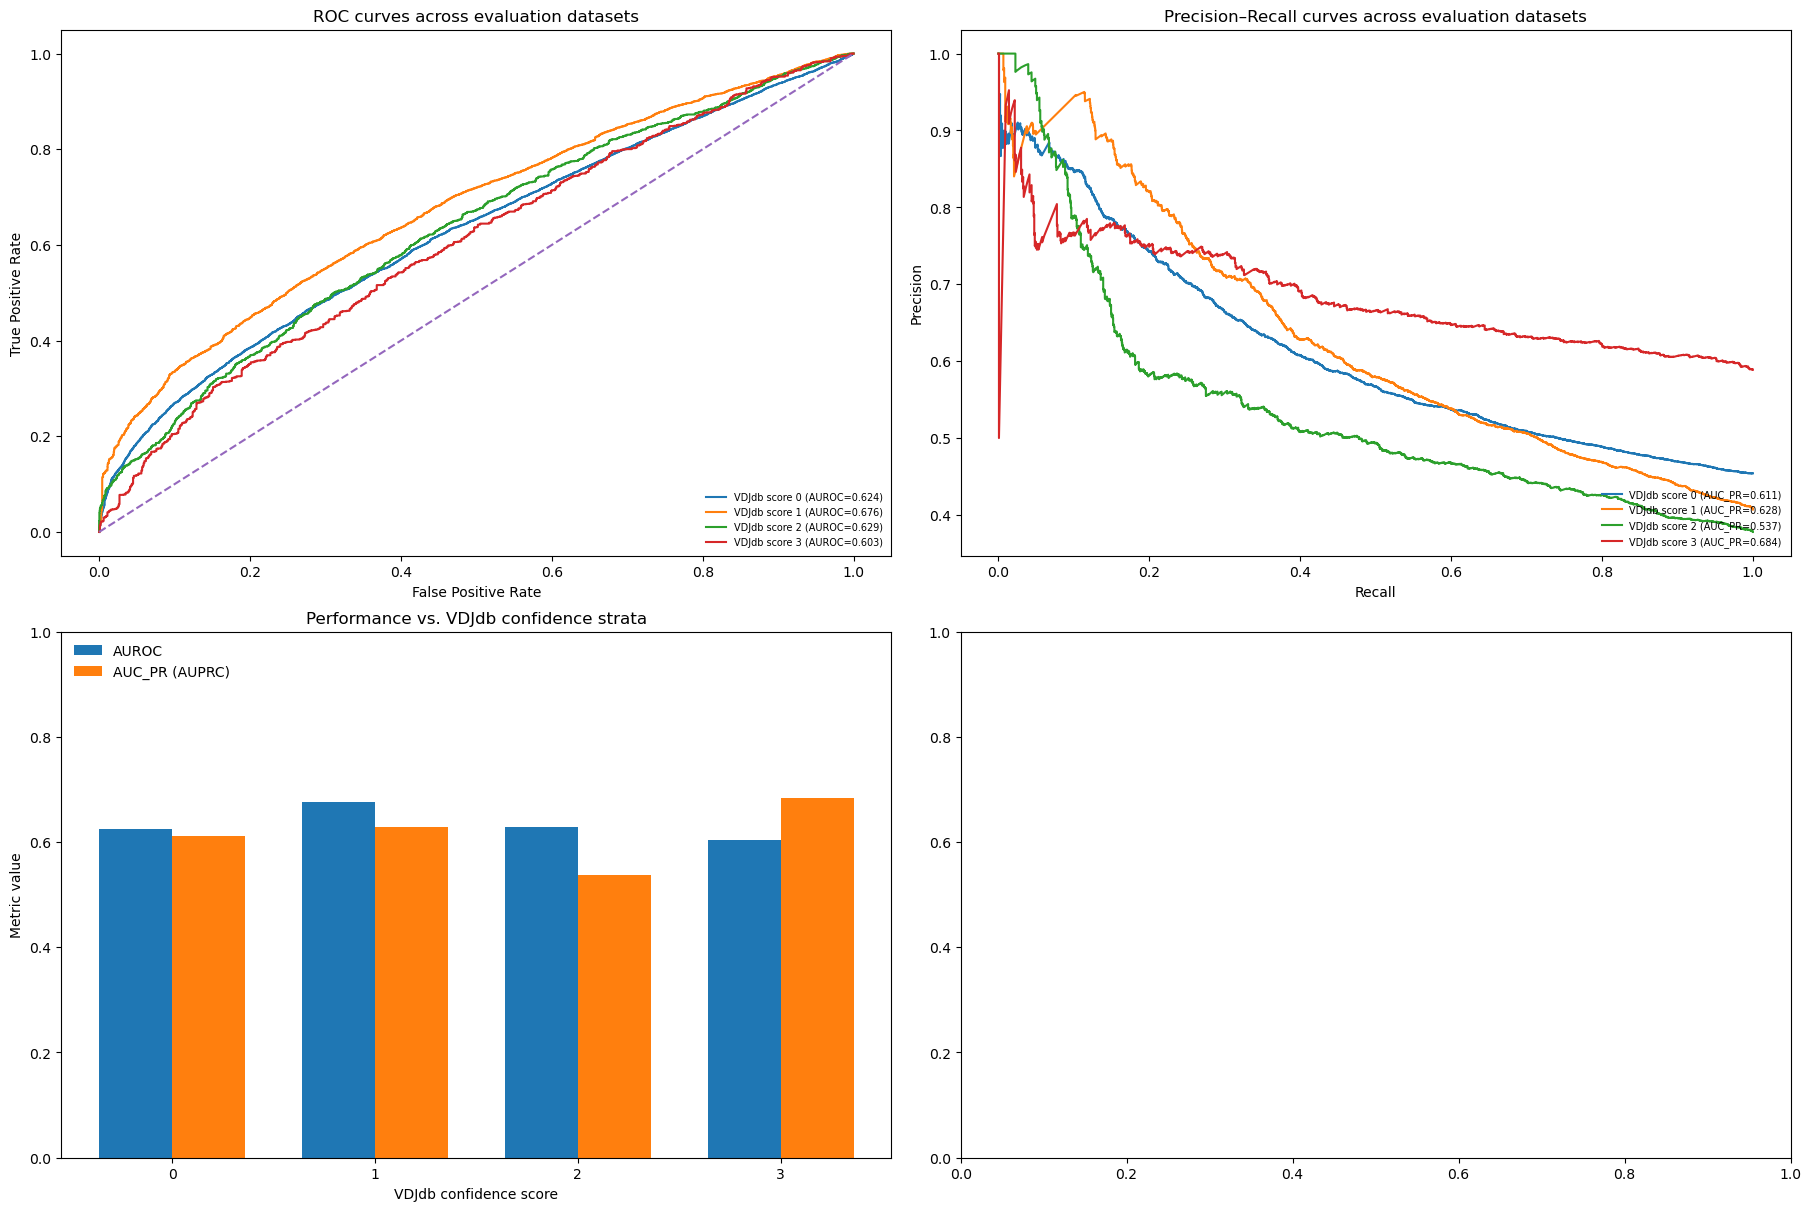

In [24]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)

# -----------------------------
# Config
# -----------------------------
DATASETS = {
    "VDJdb score 0": "output/models/0.08_mst_enrich/results/max/vdj0.csv",
    "VDJdb score 1": "output/models/0.08_mst_enrich/results/max/vdj1.csv",
    "VDJdb score 2": "output/models/0.08_mst_enrich/results/max/vdj2.csv",
    "VDJdb score 3": "output/models/0.08_mst_enrich/results/max/vdj3.csv",
}

VDJ_ORDER = ["VDJdb score 0", "VDJdb score 1", "VDJdb score 2", "VDJdb score 3"]
GEN_ORDER = [
    "Random split (none excluded)",
    "TCR excluded",
    "Epitope excluded",
    "TCR+Epitope excluded",
]

# Optional: nicer x tick labels for panel D
GEN_XLABELS = ["Random", "No TCR overlap", "No epitope overlap", "No TCR+epitope overlap"]

OUTPATH = Path("thesis_figures/combined_first4_panels.png")
OUTPATH.parent.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Helpers
# -----------------------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"true_label", "predicted_binding_prob"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")
    df["true_label"] = df["true_label"].astype(int)
    df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)
    return df

def pr_auc(y: np.ndarray, p: np.ndarray) -> float:
    precision, recall, _ = precision_recall_curve(y, p)
    return auc(recall, precision)

def add_panel_labels(axes, labels=("A", "B", "C", "D")):
    for ax, lab in zip(axes.flat, labels):
        ax.text(
            -0.08, 1.08, lab,
            transform=ax.transAxes,
            fontsize=14,
            fontweight="bold",
            va="top",
            ha="left"
        )


# -----------------------------
# Load all dataframes
# -----------------------------
dfs = {name: load_df(path) for name, path in DATASETS.items()}


# -----------------------------
# Build 2x2 combined figure
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# ===== Panel A: ROC curves =====
ax = axes[0, 0]
for name, df in dfs.items():
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    fpr, tpr, _ = roc_curve(y, p)
    auroc = roc_auc_score(y, p)
    ax.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves across evaluation datasets")
ax.legend(fontsize=7, loc="lower right", frameon=False)

# ===== Panel B: PR curves (AUC_PR) =====
ax = axes[0, 1]
for name, df in dfs.items():
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    precision, recall, _ = precision_recall_curve(y, p)
    auprc = auc(recall, precision)
    ax.plot(recall, precision, label=f"{name} (AUC_PR={auprc:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curves across evaluation datasets")
ax.legend(fontsize=7, loc="lower right", frameon=False)

# ===== Panel C: VDJdb confidence strata bar chart =====
ax = axes[1, 0]
auroc_vals, auprc_vals = [], []
for name in VDJ_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    auroc_vals.append(roc_auc_score(y, p))
    auprc_vals.append(pr_auc(y, p))

x = np.arange(len(VDJ_ORDER))
w = 0.36
ax.bar(x - 0.18, auroc_vals, width=w, label="AUROC")
ax.bar(x + 0.18, auprc_vals, width=w, label="AUC_PR (AUPRC)")
ax.set_xticks(x)
ax.set_xticklabels(["0", "1", "2", "3"])
ax.set_ylim(0, 1.0)
ax.set_xlabel("VDJdb confidence score")
ax.set_ylabel("Metric value")
ax.set_title("Performance vs. VDJdb confidence strata")
ax.legend(frameon=False, loc="upper left")

# ===== Panel D: Generalization splits bar chart =====
ax = axes[1, 1]
auroc_vals, auprc_vals = [], []
for name in GEN_ORDER:
    df = dfs[name]
    y = df["true_label"].values
    p = df["predicted_binding_prob"].values
    auroc_vals.append(roc_auc_score(y, p))
    auprc_vals.append(pr_auc(y, p))

x = np.arange(len(GEN_ORDER))
ax.bar(x - 0.18, auroc_vals, width=w, label="AUROC")
ax.bar(x + 0.18, auprc_vals, width=w, label="AUC_PR (AUPRC)")
ax.set_xticks(x)
ax.set_xticklabels(GEN_XLABELS, rotation=15, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Metric value")
ax.set_title("Generalization across overlap-exclusion splits")
ax.legend(frameon=False, loc="upper left")

# Panel labels A/B/C/D
add_panel_labels(axes)

plt.show()

# Optional save
fig.savefig(OUTPATH, dpi=220, bbox_inches="tight")
print(f"Saved combined figure to: {OUTPATH.resolve()}")


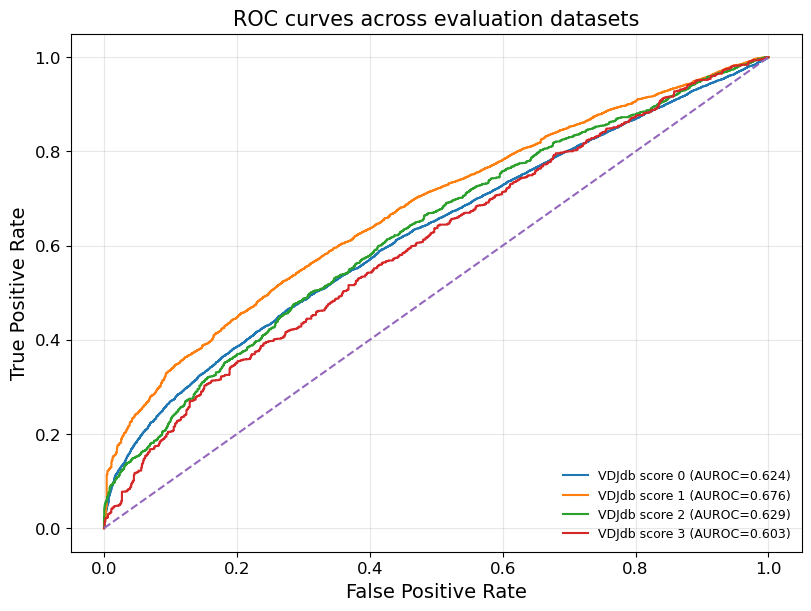

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

# -----------------------------
# Config
# -----------------------------
DATASETS = {
    "VDJdb score 0": "output/models/0.08_mst_enrich/results/max/vdj0.csv",
    "VDJdb score 1": "output/models/0.08_mst_enrich/results/max/vdj1.csv",
    "VDJdb score 2": "output/models/0.08_mst_enrich/results/max/vdj2.csv",
    "VDJdb score 3": "output/models/0.08_mst_enrich/results/max/vdj3.csv",
}

# -----------------------------
# Helpers
# -----------------------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"true_label", "predicted_binding_prob"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")
    df["true_label"] = df["true_label"].astype(int)
    df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)
    return df

# -----------------------------
# Load all dataframes
# -----------------------------
dfs = {name: load_df(path) for name, path in DATASETS.items()}

# -----------------------------
# Plot (graph only; no saving/printing)
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

for name, df in dfs.items():
    y = df["true_label"].to_numpy()
    p = df["predicted_binding_prob"].to_numpy()

    fpr, tpr, _ = roc_curve(y, p)
    auroc = roc_auc_score(y, p)

    ax.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC curves across evaluation datasets", fontsize=15)
ax.tick_params(axis="both", labelsize=12)
ax.legend(fontsize=9, loc="lower right", frameon=False)
ax.grid(True, alpha=0.3)

plt.show()


In [ ]:
# Plot comparison CSV (uses existing `df_cmp` if present, otherwise reads `path`)
from os import path
import matplotlib.pyplot as plt

# use existing dataframe if available
if 'df_cmp' in globals():
    df_plot = df_cmp.copy()
else:
    df_plot = pd.read_csv(path)

required = {"Model", "based", "ROCAUC"}
if not required.issubset(df_plot.columns):
    raise ValueError(f"CSV missing required columns: {required - set(df_plot.columns)}")

# Pivot so each 'based' becomes a bar group per Model
pivot = df_plot.pivot(index="Model", columns="based", values="ROCAUC")

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("AUROC", fontsize=14)
ax.set_xlabel("Model", fontsize=14)
ax.set_title("Model AUROC by evaluation basis", fontsize=14)
ax.legend(title="Based", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ValueError: Invalid file path or buffer object type: <class 'module'>

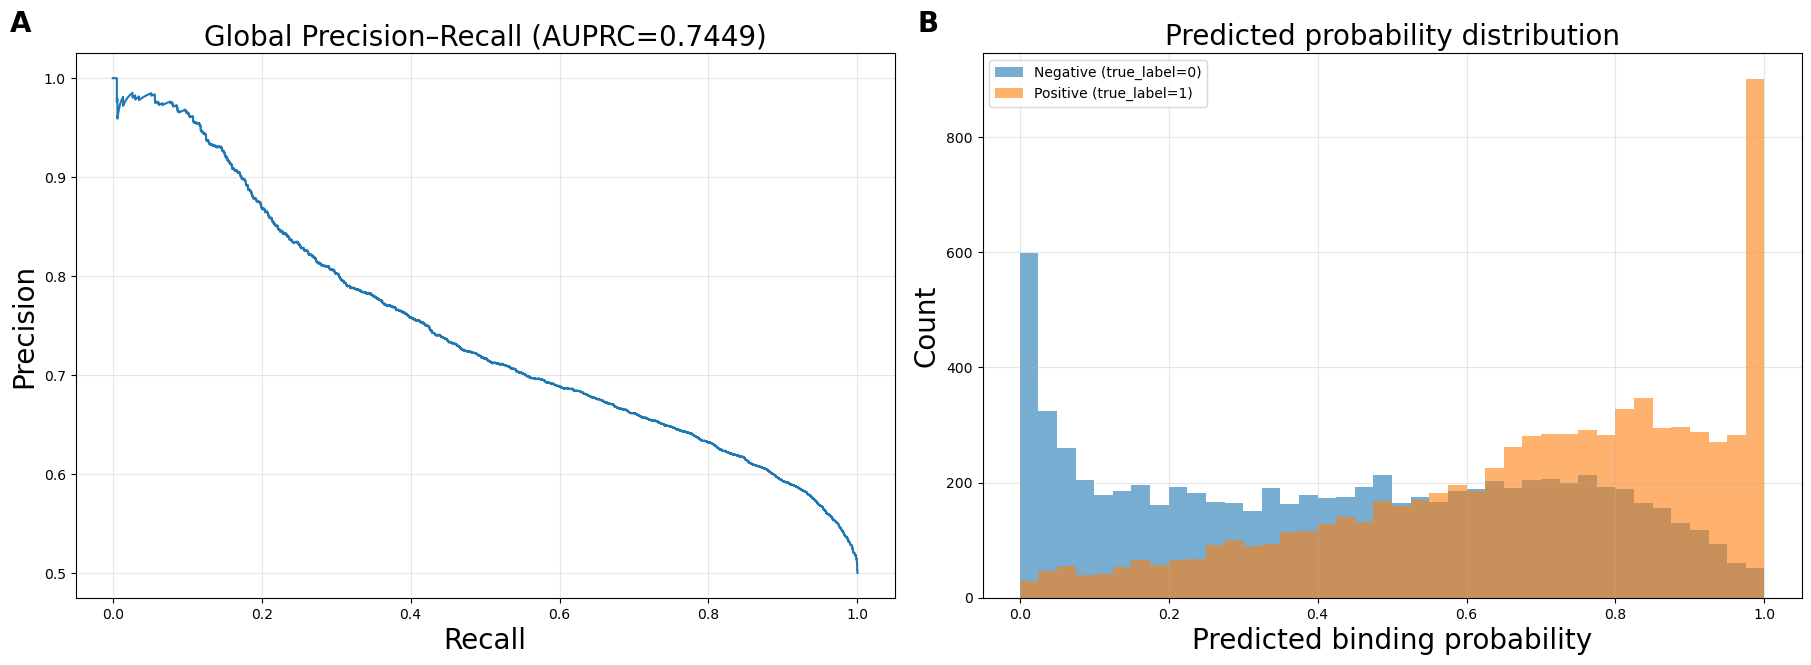

In [25]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

def add_panel_labels(axes, labels=("A", "B")):
    for ax, lab in zip(axes.flat, labels):
        ax.text(
            -0.08, 1.08, lab,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            ha="left"
        )

# ====== Load ======
df = pd.read_csv("output/models/0.08_mst_enrich/results/max/test.csv")
df["true_label"] = df["true_label"].astype(int)
df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)

out_dir = "output/models/0.08_mst_enrich/results/max/tcr_epitope_plots"
os.makedirs(out_dir, exist_ok=True)

y = df["true_label"].values
p = df["predicted_binding_prob"].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# ====== 1) Global PR curve ======

ax = axes[0, 0]
prec, rec, _ = precision_recall_curve(y, p)
auprc = average_precision_score(y, p)

# plt.figure()
ax.plot(rec, prec)
ax.set_xlabel("Recall", fontsize=20)
ax.set_ylabel("Precision", fontsize=20)
ax.set_title(f"Global Precision–Recall (AUPRC={auprc:.4f})", fontsize=20)
ax.grid(True, alpha=0.3)

# ====== 2) Probability distributions ======
pos = df.loc[df["true_label"] == 1, "predicted_binding_prob"].values
neg = df.loc[df["true_label"] == 0, "predicted_binding_prob"].values
bins = np.linspace(0, 1, 41)

ax = axes[0, 1]
ax.hist(neg, bins=bins, alpha=0.6, label="Negative (true_label=0)")
ax.hist(pos, bins=bins, alpha=0.6, label="Positive (true_label=1)")
ax.set_xlabel("Predicted binding probability", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
ax.set_title("Predicted probability distribution", fontsize=20)
ax.legend()
ax.grid(True, alpha=0.3)

fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 0])

add_panel_labels(axes[:1], labels=("A", "B"))
plt.show()



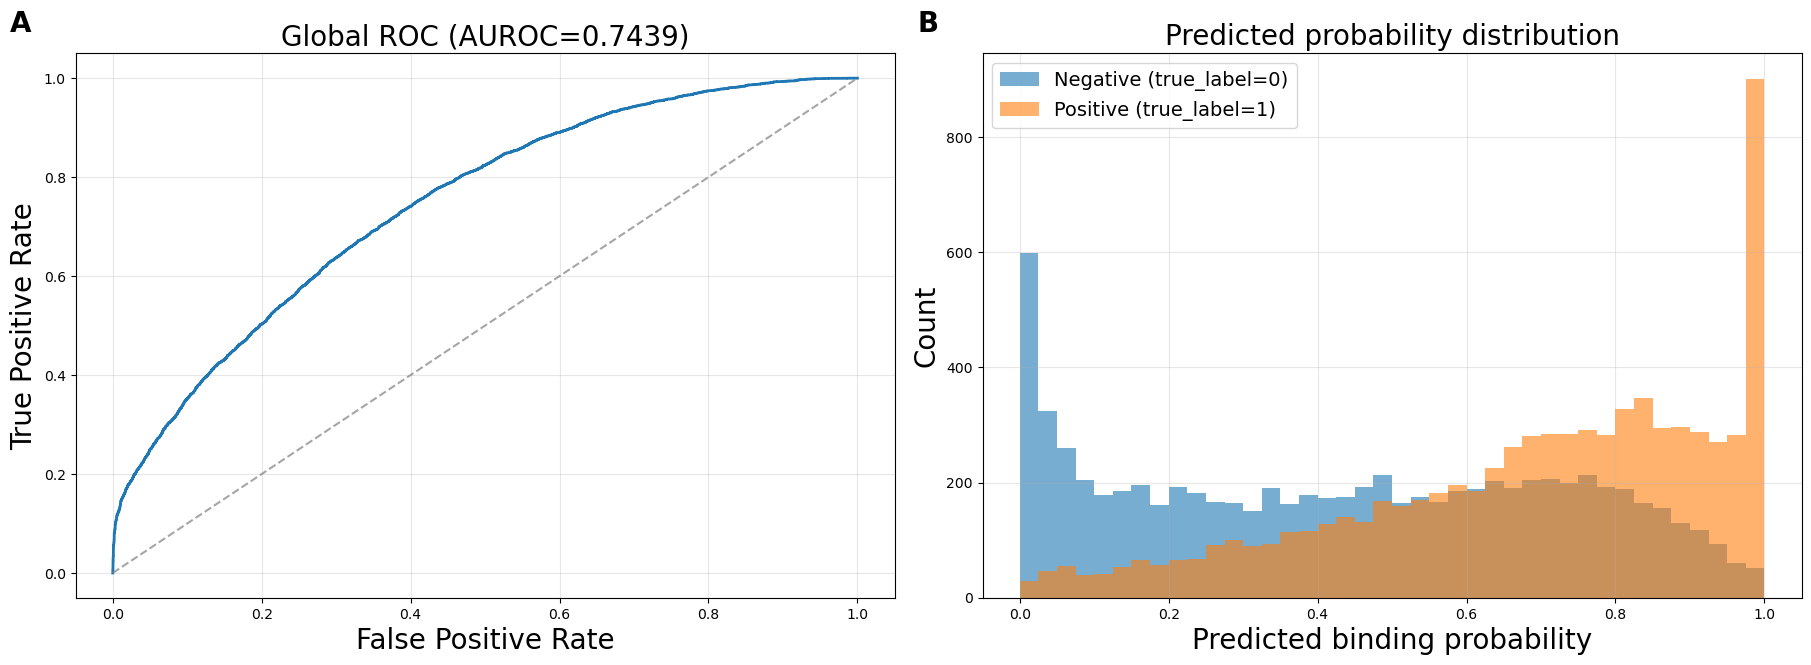

In [26]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import (
    roc_auc_score, roc_curve
)

def add_panel_labels(axes, labels=("A", "B")):
    for ax, lab in zip(axes.flat, labels):
        ax.text(
            -0.08, 1.08, lab,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            ha="left"
        )

# ====== Load ======
df = pd.read_csv("output/models/0.08_mst_enrich/results/max/test.csv")
df["true_label"] = df["true_label"].astype(int)
df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)

y = df["true_label"].values
p = df["predicted_binding_prob"].values

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)

# ====== 1) Global ROC curve (AUROC) ======
ax = axes[0, 0]

fpr, tpr, _ = roc_curve(y, p)
auroc = roc_auc_score(y, p)

ax.plot(fpr, tpr, lw=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.7)

ax.set_xlabel("False Positive Rate", fontsize=20)
ax.set_ylabel("True Positive Rate", fontsize=20)
ax.set_title(f"Global ROC (AUROC={auroc:.4f})", fontsize=20)
ax.grid(True, alpha=0.3)

# ====== 2) Probability distributions ======
pos = df.loc[df["true_label"] == 1, "predicted_binding_prob"].values
neg = df.loc[df["true_label"] == 0, "predicted_binding_prob"].values
bins = np.linspace(0, 1, 41)

ax = axes[0, 1]
ax.hist(neg, bins=bins, alpha=0.6, label="Negative (true_label=0)")
ax.hist(pos, bins=bins, alpha=0.6, label="Positive (true_label=1)")
ax.set_xlabel("Predicted binding probability", fontsize=20)
ax.set_ylabel("Count", fontsize=20)
ax.set_title("Predicted probability distribution", fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

# ====== Clean up layout ======
fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 0])

add_panel_labels(axes[:1], labels=("A", "B"))

plt.show()


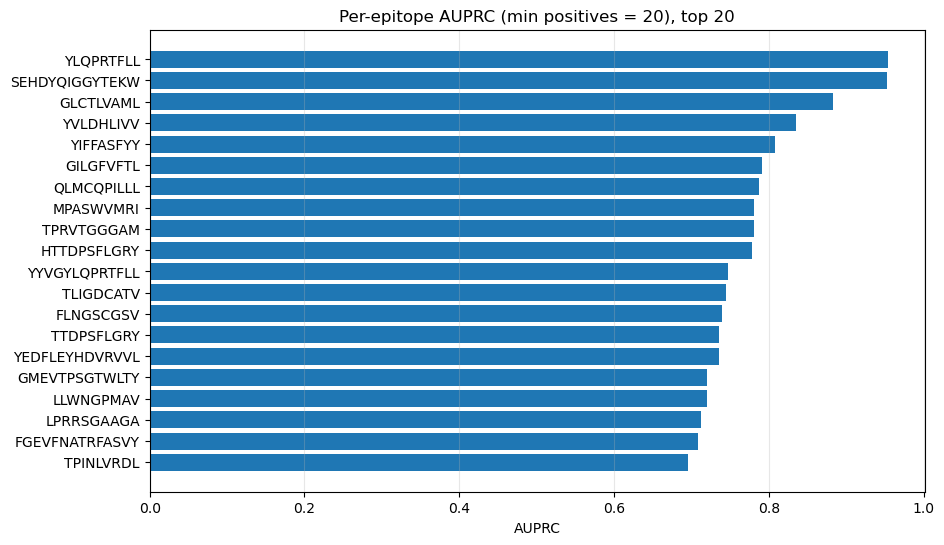

In [27]:
# ====== 3) Per-epitope AUPRC ======
min_pos = 20
per = []
for epi, g in df.groupby("epitope"):
    y_e = g["true_label"].values
    p_e = g["predicted_binding_prob"].values
    pos_ct = int((y_e == 1).sum())
    neg_ct = int((y_e == 0).sum())
    if pos_ct >= min_pos and neg_ct > 0:
        per.append((epi, pos_ct, neg_ct, average_precision_score(y_e, p_e)))

per_df = (pd.DataFrame(per, columns=["epitope", "n_pos", "n_neg", "auprc"])
          .sort_values("auprc", ascending=False))

per_df.to_csv(os.path.join(out_dir, "03_per_epitope_auprc_table.csv"), index=False)

top_n = min(20, len(per_df))
sub = per_df.head(top_n).iloc[::-1]  # for nicer horizontal ordering

plt.figure(figsize=(10, max(4, 0.25*top_n + 1)))
plt.barh(sub["epitope"], sub["auprc"])
plt.xlabel("AUPRC")
plt.title(f"Per-epitope AUPRC (min positives = {min_pos}), top {top_n}")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

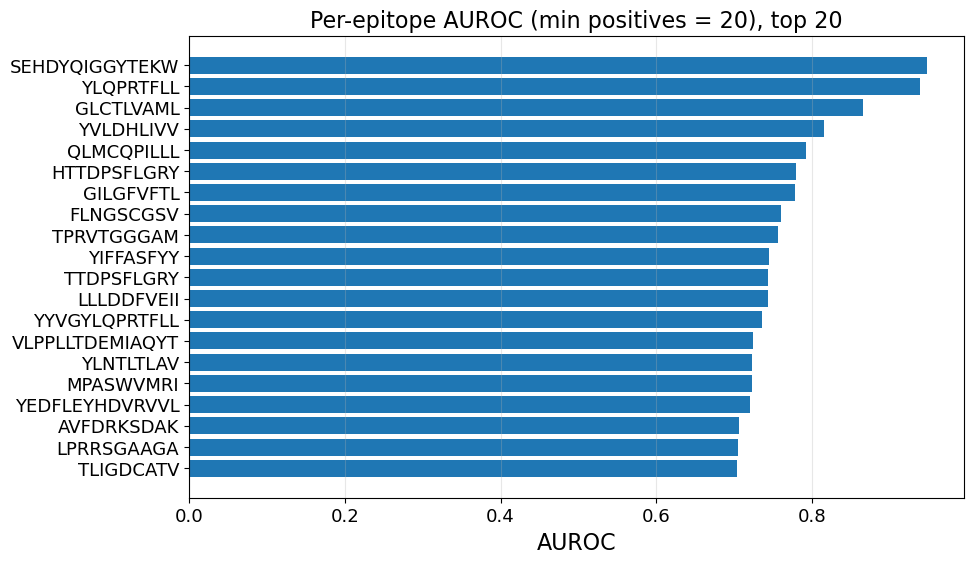

In [28]:
from sklearn.metrics import roc_auc_score

# ====== 3) Per-epitope AUROC ======
min_pos = 20
per = []

for epi, g in df.groupby("epitope"):
    y_e = g["true_label"].values
    p_e = g["predicted_binding_prob"].values

    pos_ct = int((y_e == 1).sum())
    neg_ct = int((y_e == 0).sum())

    if pos_ct >= min_pos and neg_ct > 0:
        auroc = roc_auc_score(y_e, p_e)
        per.append((epi, pos_ct, neg_ct, auroc))

per_df = (
    pd.DataFrame(per, columns=["epitope", "n_pos", "n_neg", "auroc"])
    .sort_values("auroc", ascending=False)
)

per_df.to_csv(
    os.path.join(out_dir, "03_per_epitope_auroc_table.csv"),
    index=False
)


top_n = min(20, len(per_df))
sub = per_df.head(top_n).iloc[::-1]  # nicer horizontal ordering

plt.figure(figsize=(10, max(4, 0.25 * top_n + 1)))
plt.barh(sub["epitope"], sub["auroc"])
plt.xlabel("AUROC", fontsize=16)
plt.title(f"Per-epitope AUROC (min positives = {min_pos}), top {top_n}", fontsize=16)
plt.tick_params(axis="both", labelsize=13)
plt.grid(True, axis="x", alpha=0.3)
plt.show()


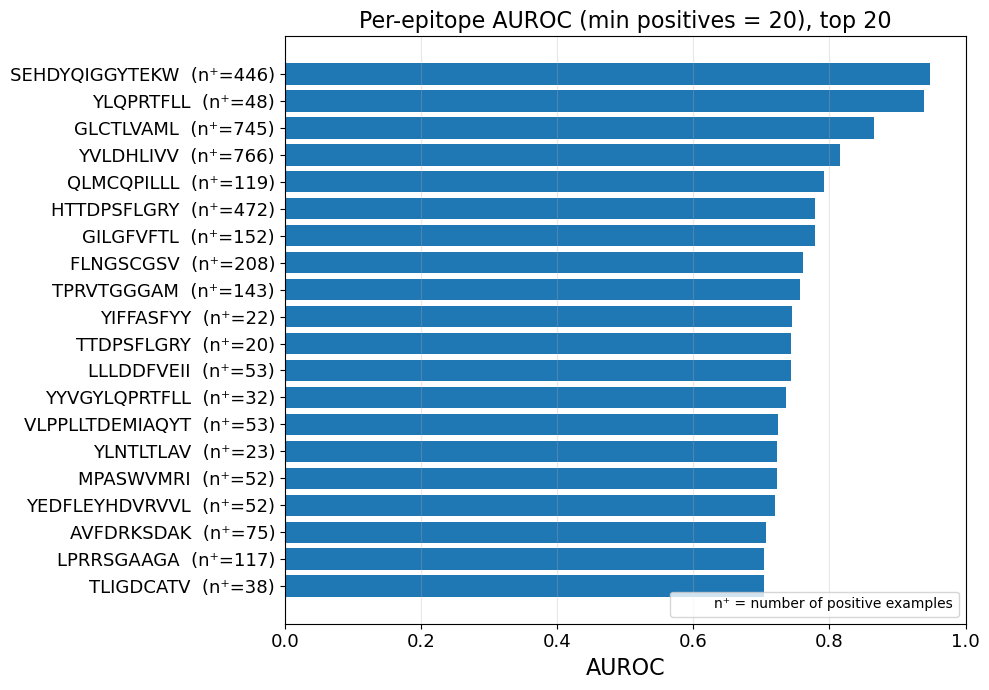

In [29]:
top_n = min(20, len(per_df))
sub = per_df.head(top_n).iloc[::-1].copy()

# Create pretty label including n_pos
sub["label"] = sub.apply(
    lambda r: f"{r['epitope']}  (n⁺={r['n_pos']})",
    axis=1
)

plt.figure(figsize=(10, max(4, 0.3 * top_n + 1)))
bars = plt.barh(sub["label"], sub["auroc"])

plt.xlabel("AUROC", fontsize=16)
plt.title(f"Per-epitope AUROC (min positives = {min_pos}), top {top_n}", fontsize=16)
plt.tick_params(axis="both", labelsize=13)
plt.grid(True, axis="x", alpha=0.3)

plt.xlim(0, 1)  # AUROC always between 0 and 1
plt.tight_layout()

from matplotlib.lines import Line2D

plt.legend(
    handles=[Line2D([0], [0], color="none",
                    label="n⁺ = number of positive examples")],
    loc="lower right",
    frameon=True
)

plt.show()

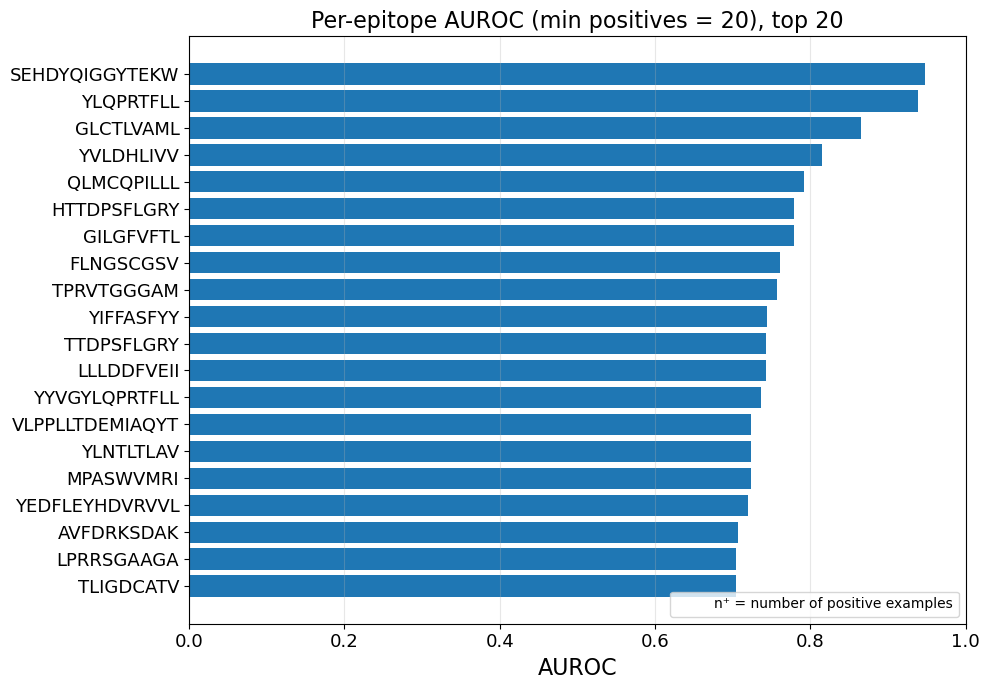

In [30]:
from matplotlib.lines import Line2D

top_n = min(20, len(per_df))
sub = per_df.head(top_n).iloc[::-1].copy()

plt.figure(figsize=(10, max(4, 0.3 * top_n + 1)))
bars = plt.barh(sub["epitope"], sub["auroc"])

plt.xlabel("AUROC", fontsize=16)
plt.title(f"Per-epitope AUROC (min positives = {min_pos}), top {top_n}", fontsize=16)
plt.tick_params(axis="both", labelsize=13)
plt.grid(True, axis="x", alpha=0.3)

# Legend explaining n⁺
legend_handle = Line2D(
    [0], [0],
    color="none",
    label="n⁺ = number of positive examples"
)
plt.legend(handles=[legend_handle], loc="lower right", frameon=True)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

# ====== Load ======
df = pd.read_csv("output/models/0.08_mst_enrich/results/max/test.csv")
df["true_label"] = df["true_label"].astype(int)
df["predicted_binding_prob"] = df["predicted_binding_prob"].astype(float)

out_dir = "output/models/0.08_mst_enrich/results/max/tcr_epitope_plots"
os.makedirs(out_dir, exist_ok=True)

y = df["true_label"].values
p = df["predicted_binding_prob"].values

# ====== 1) Global PR curve ======
prec, rec, _ = precision_recall_curve(y, p)
auprc = average_precision_score(y, p)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Global Precision–Recall (AUPRC={auprc:.4f})")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(out_dir, "01_global_pr_curve.png"), dpi=200, bbox_inches="tight")
plt.close()

# ====== 2) Probability distributions ======
pos = df.loc[df["true_label"] == 1, "predicted_binding_prob"].values
neg = df.loc[df["true_label"] == 0, "predicted_binding_prob"].values
bins = np.linspace(0, 1, 41)

plt.figure()
plt.hist(neg, bins=bins, alpha=0.6, label="Negative (true_label=0)")
plt.hist(pos, bins=bins, alpha=0.6, label="Positive (true_label=1)")
plt.xlabel("Predicted binding probability")
plt.ylabel("Count")
plt.title("Predicted probability distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(out_dir, "02_probability_distributions.png"), dpi=200, bbox_inches="tight")
plt.close()

# ====== 3) Per-epitope AUPRC ======
min_pos = 20
per = []
for epi, g in df.groupby("epitope"):
    y_e = g["true_label"].values
    p_e = g["predicted_binding_prob"].values
    pos_ct = int((y_e == 1).sum())
    neg_ct = int((y_e == 0).sum())
    if pos_ct >= min_pos and neg_ct > 0:
        per.append((epi, pos_ct, neg_ct, average_precision_score(y_e, p_e)))

per_df = (pd.DataFrame(per, columns=["epitope", "n_pos", "n_neg", "auprc"])
          .sort_values("auprc", ascending=False))

per_df.to_csv(os.path.join(out_dir, "03_per_epitope_auprc_table.csv"), index=False)

top_n = min(20, len(per_df))
sub = per_df.head(top_n).iloc[::-1]  # for nicer horizontal ordering

plt.figure(figsize=(10, max(4, 0.25*top_n + 1)))
plt.barh(sub["epitope"], sub["auprc"])
plt.xlabel("AUPRC")
plt.title(f"Per-epitope AUPRC (min positives = {min_pos}), top {top_n}")
plt.grid(True, axis="x", alpha=0.3)
plt.savefig(os.path.join(out_dir, "03_per_epitope_auprc_top20.png"), dpi=200, bbox_inches="tight")
plt.close()

# ====== 4) Recall@k (retrieval style) ======
ks = [1, 3, 5, 10, 20, 50]
hits_at_k = {k: 0 for k in ks}
eligible_tcrs = 0

for tcr, g in df.groupby("tcr"):
    y_t = g["true_label"].values
    if (y_t == 1).sum() == 0:
        continue
    eligible_tcrs += 1
    g_sorted = g.sort_values("predicted_binding_prob", ascending=False)
    y_sorted = g_sorted["true_label"].values

    for k in ks:
        k_eff = min(k, len(g_sorted))
        if (y_sorted[:k_eff] == 1).any():
            hits_at_k[k] += 1

recall_at_k = {k: hits_at_k[k] / eligible_tcrs for k in ks}

plt.figure()
plt.plot(ks, [recall_at_k[k] for k in ks], marker="o")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (Top-k)")
plt.ylabel("Recall@k (fraction of TCRs with a true epitope in Top-k)")
plt.title(f"Recall@k over {eligible_tcrs} eligible TCRs")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(out_dir, "04_recall_at_k.png"), dpi=200, bbox_inches="tight")
plt.close()

# ====== 5) Calibration (Reliability diagram) ======
prob_true, prob_pred = calibration_curve(y, p, n_bins=10, strategy="uniform")
brier = brier_score_loss(y, p)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Calibration (Brier={brier:.4f})")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(out_dir, "05_calibration.png"), dpi=200, bbox_inches="tight")
plt.close()

# ====== 6) ROC curve (optional) ======
fpr, tpr, _ = roc_curve(y, p)
auroc = roc_auc_score(y, p)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC (AUROC={auroc:.4f})")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(out_dir, "06_roc_curve.png"), dpi=200, bbox_inches="tight")
plt.close()

print("Saved plots to:", out_dir)


Saved plots to: output/models/0.08_mst_enrich/results/max/tcr_epitope_plots


In [32]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

# Find all test.csv files in output/models/*/results/
results_pattern = Path("output/models")
test_files = list(results_pattern.glob("*/results/*/test.csv"))

if not test_files:
    print("No test.csv files found in output/models/*/results/")
else:
    print(f"Found {len(test_files)} test.csv files\n")
    
    run_metrics = []
    
    for test_file in test_files:
        try:
            test_df = pd.read_csv(test_file)
            y_test = test_df["true_label"].values
            p_test = test_df["predicted_binding_prob"].values
            
            auroc = roc_auc_score(y_test, p_test)
            acc = accuracy_score(y_test, p_test >= 0.5)
            
            run_metrics.append({
                "path": str(test_file),
                "run": test_file.parts[-4],  # model directory name
                "split": test_file.parts[-2],  # min/max/etc
                "AUROC": auroc,
                "Accuracy": acc,
                "N": len(test_df)
            })
        except Exception as e:
            print(f"Error processing {test_file}: {e}")
    
    if run_metrics:
        metrics_df = pd.DataFrame(run_metrics)
        
        # Find best AUROC
        best_auc_idx = metrics_df["AUROC"].idxmax()
        best_auc = metrics_df.loc[best_auc_idx]
        
        # Find best Accuracy
        best_acc_idx = metrics_df["Accuracy"].idxmax()
        best_acc = metrics_df.loc[best_acc_idx]
        
        print("=" * 80)
        print("BEST AUROC:")
        print("=" * 80)
        print(f"Run: {best_auc['run']}")
        print(f"Split: {best_auc['split']}")
        print(f"Path: {best_auc['path']}")
        print(f"AUROC: {best_auc['AUROC']:.4f}")
        print(f"Accuracy: {best_auc['Accuracy']:.4f}")
        print(f"N: {best_auc['N']}")
        
        print("\n" + "=" * 80)
        print("BEST ACCURACY:")
        print("=" * 80)
        print(f"Run: {best_acc['run']}")
        print(f"Split: {best_acc['split']}")
        print(f"Path: {best_acc['path']}")
        print(f"AUROC: {best_acc['AUROC']:.4f}")
        print(f"Accuracy: {best_acc['Accuracy']:.4f}")
        print(f"N: {best_acc['N']}")
        
        print("\n" + "=" * 80)
        print(f"All runs summary (sorted by AUROC):")
        print("=" * 80)
        print(metrics_df.sort_values("AUROC", ascending=False).to_string(index=False))

Found 22 test.csv files

BEST AUROC:
Run: 0.08_mst_enrich
Split: max
Path: output/models/0.08_mst_enrich/results/max/test.csv
AUROC: 0.7439
Accuracy: 0.6706
N: 15000

BEST ACCURACY:
Run: 0.08_mst_enrich
Split: min
Path: output/models/0.08_mst_enrich/results/min/test.csv
AUROC: 0.7439
Accuracy: 0.6706
N: 15000

All runs summary (sorted by AUROC):
                                              path             run split    AUROC  Accuracy     N
output/models/0.08_mst_enrich/results/max/test.csv 0.08_mst_enrich   max 0.743903  0.670600 15000
output/models/0.08_mst_enrich/results/min/test.csv 0.08_mst_enrich   min 0.743903  0.670600 15000
    output/models/0.1__enrich/results/min/test.csv     0.1__enrich   min 0.743282  0.665933 15000
    output/models/0.1__enrich/results/max/test.csv     0.1__enrich   max 0.743282  0.665933 15000
   output/models/0.05__enrich/results/min/test.csv    0.05__enrich   min 0.737827  0.664333 15000
   output/models/0.05__enrich/results/max/test.csv    0.05__enri

In [33]:
# Aggregate run-level performance and pick the best overall run
# Uses existing `results_all` DataFrame from earlier cells.

# Aggregate by run
agg = (
    results_all
    .groupby("run")
    .agg(
        AUROC_mean=("AUROC", "mean"),
        AUROC_std=("AUROC", "std"),
        Accuracy_mean=("Accuracy", "mean"),
        Accuracy_std=("Accuracy", "std"),
        N=("N", "first")
    )
    .sort_values(["AUROC_mean", "Accuracy_mean"], ascending=False)
)

# Best run (primary sort by AUROC_mean, tie-breaker by Accuracy_mean)
best_run_name = agg.index[0]
best_run_agg = agg.loc[best_run_name]

# All result rows for the best run (both splits if present)
best_run_results = results_all[results_all["run"] == best_run_name].reset_index(drop=True)

# Print concise summary
print("Best overall run (by AUROC_mean, tie-breaker Accuracy_mean):")
print("-" * 60)
print(f"Run name: {best_run_name}")
print(f"AUROC_mean: {best_run_agg['AUROC_mean']:.6f} ± {best_run_agg['AUROC_std']:.6f}")
print(f"Accuracy_mean: {best_run_agg['Accuracy_mean']:.6f} ± {best_run_agg['Accuracy_std']:.6f}")
print(f"N (per-split): {int(best_run_agg['N'])}")
print("\nPer-split entries for this run:")
print(best_run_results[["path", "split", "AUROC", "Accuracy", "N"]].to_string(index=False))

# Expose variables for downstream use
best_overall_run_name = best_run_name
best_overall_run_agg = best_run_agg
best_overall_run_results = best_run_results

NameError: name 'results_all' is not defined

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score

# Define the 9 dataset types to evaluate
DATASET_TYPES = [
    # "vdj0.csv",
    # "vdj1.csv", 
    # "vdj2.csv",
    # "vdj3.csv",
    "test.csv",
    # "none_excluded_vdj0.csv",
    # "cdr3_excluded_vdj0.csv",
    # "peptide_excluded_vdj0.csv",
    # "cdr3_and_peptide_excluded_vdj0.csv"
]

# Find all model directories
models_dir = Path("output/models")
model_dirs = [d for d in models_dir.iterdir() if d.is_dir()]

# Collect performance across all datasets for each model
all_model_results = []

for model_dir in model_dirs:
    model_name = model_dir.name
    
    # Check both min and max splits
    for split in ["max"]:
        results_dir = model_dir / "results" / split
        
        if not results_dir.exists():
            continue
            
        split_aurocs = []
        split_accs = []
        dataset_count = 0
        
        # Evaluate on each dataset type
        for dataset_file in DATASET_TYPES:
            dataset_path = results_dir / dataset_file
            
            if not dataset_path.exists():
                continue
                
            try:
                df = pd.read_csv(dataset_path)
                y_true = df["true_label"].values
                y_pred = df["predicted_binding_prob"].values
                
                auroc = roc_auc_score(y_true, y_pred)
                acc = accuracy_score(y_true, y_pred >= 0.5)
                
                split_aurocs.append(auroc)
                split_accs.append(acc)
                dataset_count += 1
                
            except Exception as e:
                print(f"Error processing {dataset_path}: {e}")
                continue
        
        if dataset_count > 0:
            all_model_results.append({
                "model": model_name,
                "split": split,
                "n_datasets": dataset_count,
                "mean_auroc": np.mean(split_aurocs),
                "std_auroc": np.std(split_aurocs),
                "mean_accuracy": np.mean(split_accs),
                "std_accuracy": np.std(split_accs),
                "min_auroc": np.min(split_aurocs),
                "max_auroc": np.max(split_aurocs)
            })

# Create summary DataFrame
summary_df = pd.DataFrame(all_model_results)

# Aggregate by model (average across splits)
model_aggregate = (
    summary_df
    .groupby("model")
    .agg({
        "n_datasets": "first",
        "mean_auroc": "mean",
        "std_auroc": "mean",
        "mean_accuracy": "mean",
        "std_accuracy": "mean",
        "min_auroc": "mean",
        "max_auroc": "mean"
    })
    .sort_values("mean_auroc", ascending=False)
)

# Best overall model
best_model_name = model_aggregate.index[0]
best_model_stats = model_aggregate.loc[best_model_name]

print("=" * 80)
print("BEST OVERALL MODEL ACROSS ALL 9 DATASETS:")
print("=" * 80)
print(f"Model: {best_model_name}")
print(f"Number of datasets evaluated: {int(best_model_stats['n_datasets'])}")
print(f"Mean AUROC: {best_model_stats['mean_auroc']:.6f} ± {best_model_stats['std_auroc']:.6f}")
print(f"Mean Accuracy: {best_model_stats['mean_accuracy']:.6f} ± {best_model_stats['std_accuracy']:.6f}")
print(f"Min AUROC (across datasets): {best_model_stats['min_auroc']:.6f}")
print(f"Max AUROC (across datasets): {best_model_stats['max_auroc']:.6f}")

print("\n" + "=" * 80)
print("ALL MODELS RANKED BY MEAN AUROC:")
print("=" * 80)
print(model_aggregate.to_string())

# Export detailed results
summary_df.to_csv("output/all_models_all_datasets_summary.csv", index=False)
model_aggregate.to_csv("output/models_aggregate_performance.csv")
print(f"\nDetailed results saved to output/all_models_all_datasets_summary.csv")
print(f"Aggregate results saved to output/models_aggregate_performance.csv")

BEST OVERALL MODEL ACROSS ALL 9 DATASETS:
Model: 0.08_mst_enrich
Number of datasets evaluated: 1
Mean AUROC: 0.743903 ± 0.000000
Mean Accuracy: 0.670600 ± 0.000000
Min AUROC (across datasets): 0.743903
Max AUROC (across datasets): 0.743903

ALL MODELS RANKED BY MEAN AUROC:
                 n_datasets  mean_auroc  std_auroc  mean_accuracy  std_accuracy  min_auroc  max_auroc
model                                                                                                
0.08_mst_enrich           1    0.743903        0.0       0.670600           0.0   0.743903   0.743903
0.1__enrich               1    0.743282        0.0       0.665933           0.0   0.743282   0.743282
0.05__enrich              1    0.737827        0.0       0.664333           0.0   0.737827   0.737827
0.08__enrich              1    0.737609        0.0       0.662133           0.0   0.737609   0.737609
0.02_mst_enrich           1    0.736609        0.0       0.659400           0.0   0.736609   0.736609
0.1_mst_enri

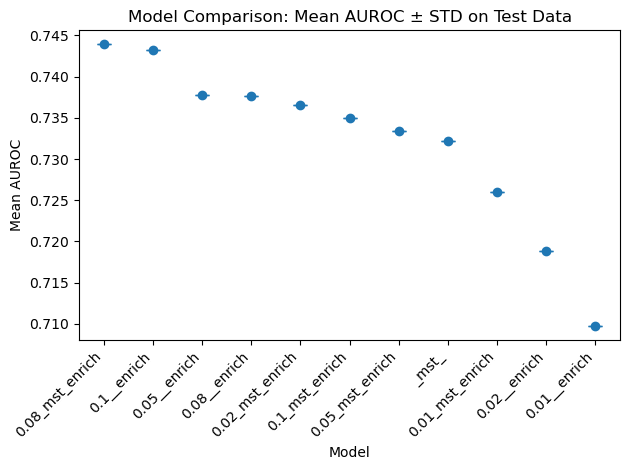

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load aggregate results
df = pd.read_csv("output/models_aggregate_performance.csv", index_col=0)

plt.figure()
plt.errorbar(
    df.index,
    df["mean_auroc"],
    yerr=df["std_auroc"],
    fmt='o',
    capsize=5
)

plt.xlabel("Model")
plt.ylabel("Mean AUROC")
plt.title("Model Comparison: Mean AUROC ± STD on Test Data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


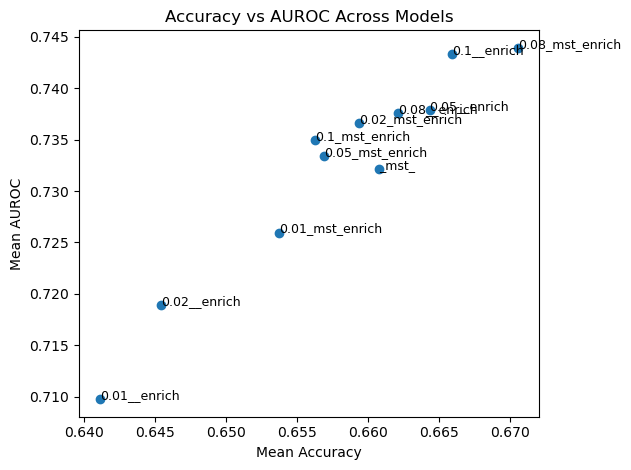

In [ ]:
plt.figure()

plt.scatter(df["mean_accuracy"], df["mean_auroc"])
for model in df.index:
    plt.text(
        df.loc[model, "mean_accuracy"],
        df.loc[model, "mean_auroc"],
        model,
        fontsize=9
    )

plt.xlabel("Mean Accuracy")
plt.ylabel("Mean AUROC")
plt.title("Accuracy vs AUROC Across Models")
plt.tight_layout()
plt.show()
